In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Superstore.csv")

df.head()

In [ ]:
required_cols = ["Sales", "Order Date", "Product Name", "Category", "Customer Name", "Region"]

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")
    

In [ ]:
#covert Sales to numeric
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

#covert Oredr Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

#drop missing values
df = df.dropna(subset=["Sales", "Order Date"]).copy()

df.info()

In [ ]:
#create Year-month column
df.loc[:, "year_month"] = df["Order Date"].dt.to_period("M")

In [ ]:
#Total Revenue

total_revenue = df["Sales"].sum()
print(f"Total Revenue:{total_revenue:,.2f}")

In [ ]:
#Top selling Product

top_product = (
    df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)
)
print("Top Selling Product:")
print(top_product.head(1))

In [ ]:
#Month with Highest Sales

Monthly_sales = (
    df.groupby("year_month")["Sales"].sum().sort_values(ascending=False)
)

print("Month with Highest Sale:")
print(Monthly_sales.head(1))

In [ ]:
#Top 5 customers

top_customers = (
    df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)
)

print("Top 5 Customers:")
print(top_customers)

In [ ]:
#Region with Highest Revenue

Sales_by_region = (
    df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
)

print("Top Region:")
print(Sales_by_region.head(1))

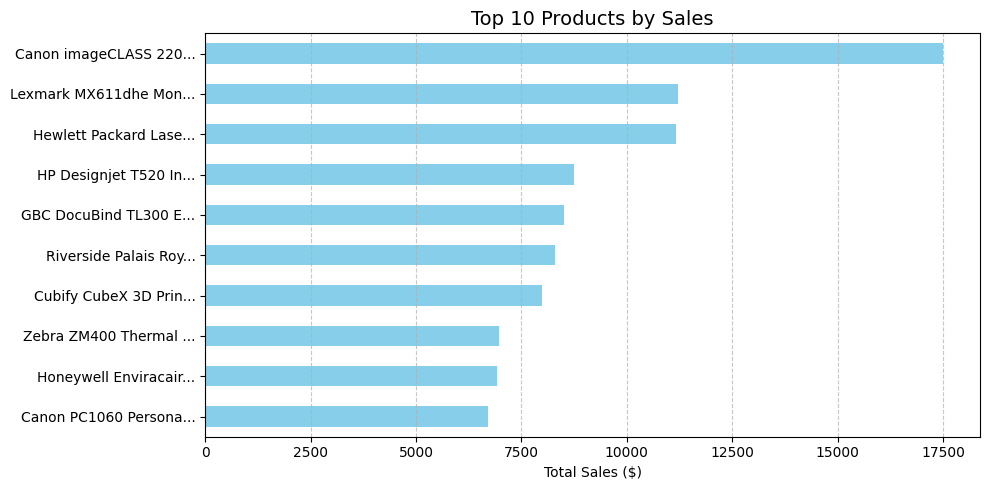

In [57]:
#Visualization Section
#Top 10 Product

top_product.head(10).sort_values(ascending=True).plot(kind="barh", figsize=(10,5), color="Skyblue")
plt.title("Top 10 Products by Sales", fontsize=14)
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


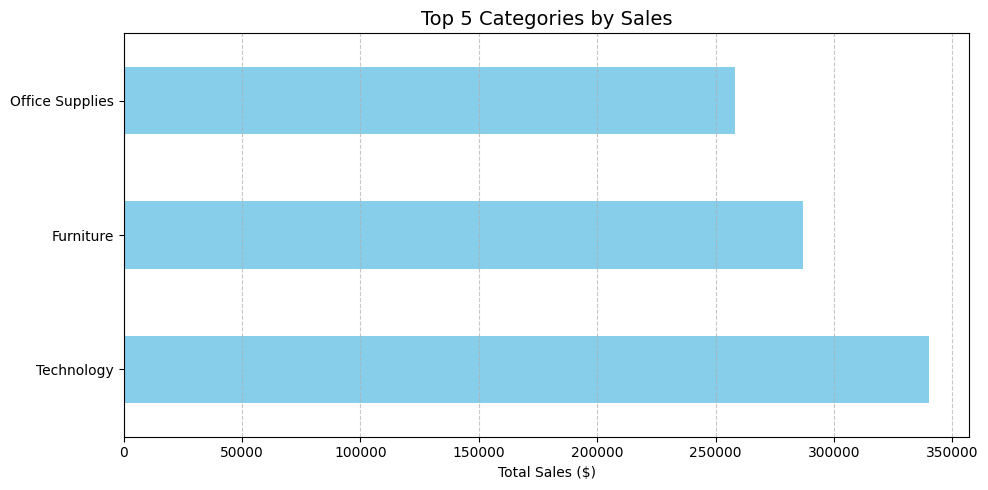

In [58]:
#Top 3 category

top_category = (df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

top_category.head(3).plot(kind="barh", figsize=(10,5), color="Skyblue")
plt.title("Top 5 Categories by Sales", fontsize=14)
plt.xlabel("Total Sales ($)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

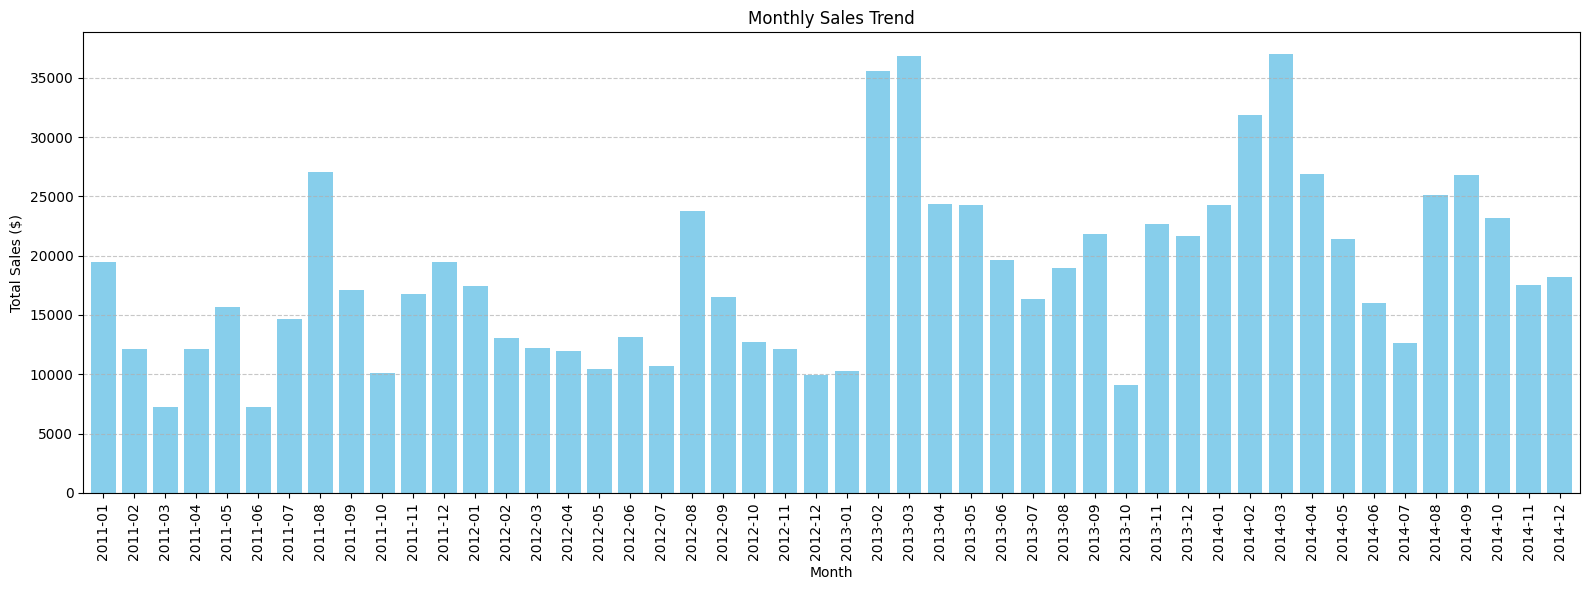

In [61]:
#Monthly sales Trend

monthly_sales_sorted = df.groupby("year_month")["Sales"].sum().sort_index()
monthly_sales_sorted.plot(kind="bar", figsize=(16,6), color="Skyblue", width=0.8)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [65]:
top_product.head(10).to_csv("top_10_products.csv")
top_customers.to_csv("top_5_customers.csv")
Sales_by_region.to_csv("Sales_by_region")